# Machine Learning: Predictive Modelling

This notebook performs predictive modeling tasks on the `titanic_cleaned.csv` dataset, focusing on:

1.  **Train/Test Split**: Preparing data for model training and evaluation.
2.  **Regression (Linear Regression)**: Predicting `Fare`.
3.  **Classification (Logistic Regression)**: Predicting `Survival`.
4.  **Model Evaluation**: Generating metrics and visualizations for both models.

## Setup and Imports

First, we'll import all necessary libraries and set up global configurations, including warnings, plotting themes, and paths.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, precision_recall_curve
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

PALETTE = "Set2"
C1, C2  = "#5fa8d3", "#e07b54"
FIG_BG  = "#f9f9f9"
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.facecolor": FIG_BG, "axes.facecolor": FIG_BG,
                     "font.family": "DejaVu Sans", "figure.dpi": 150})

DATA_PATH = "titanic_cleaned.csv"

# Create output directory if it doesn't exist
OUTPUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries imported and global settings applied.")
print(f"Output directory created at: {OUTPUT_DIR}")

Libraries imported and global settings applied.
Output directory created at: /mnt/user-data/outputs


## Load Data

We'll load the `titanic_cleaned.csv` dataset, convert relevant columns to appropriate types, and display its basic information.

In [2]:
df = pd.read_csv(DATA_PATH)
df["Survived"] = df["Survived"].astype(int)
df["Pclass"]   = df["Pclass"].astype(int)

display(df.head(10))
print(f"Dataset shape: {df.shape}")
print(f"Data Types:\n{df.dtypes.to_string()}")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FamilySize,IsAlone,AgeGroup,FareBand
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0,YoungAdult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0,Adult,Very High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1,YoungAdult,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0,YoungAdult,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1,YoungAdult,Medium
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,0,1,1,YoungAdult,Medium
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,1,1,1,Adult,Very High
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,0,5,0,Child,High
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,0,3,0,YoungAdult,Medium
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,0,2,0,Teen,High


Dataset shape: (891, 16)
Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Has_Cabin        int64
FamilySize       int64
IsAlone          int64
AgeGroup        object
FareBand        object


## Pre-processing

This section involves feature engineering and encoding for the machine learning models. We'll create encoded versions of categorical features and a log-transformed `Fare`.

In [3]:
df_ml = df.copy()
le_sex = LabelEncoder()
df_ml["Sex_enc"] = le_sex.fit_transform(df_ml["Sex"])
le_emb = LabelEncoder()
df_ml["Embarked_enc"] = le_emb.fit_transform(df_ml["Embarked"].astype(str))
df_ml["LogFare"] = np.log1p(df_ml["Fare"])

print("Features 'Sex', 'Embarked', and 'Fare' have been preprocessed to 'Sex_enc', 'Embarked_enc', and 'LogFare' respectively.")
display(df_ml.head())

Features 'Sex', 'Embarked', and 'Fare' have been preprocessed to 'Sex_enc', 'Embarked_enc', and 'LogFare' respectively.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FamilySize,IsAlone,AgeGroup,FareBand,Sex_enc,Embarked_enc,LogFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0,YoungAdult,Low,1,2,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0,Adult,Very High,0,0,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1,YoungAdult,Medium,0,2,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0,YoungAdult,Very High,0,2,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1,YoungAdult,Medium,1,2,2.202765


## Task 1: Train / Test Split

We'll split the data into training and testing sets for both regression (predicting `LogFare`) and classification (predicting `Survived`). For classification, we use stratified sampling to maintain class balance.

In [4]:
REG_FEATURES = ["Pclass","Age","Sex_enc","SibSp","Parch","FamilySize","IsAlone","Has_Cabin","Embarked_enc"]
REG_TARGET   = "LogFare"
CLF_FEATURES = ["Pclass","Age","Sex_enc","SibSp","Parch","LogFare","FamilySize","IsAlone","Has_Cabin","Embarked_enc"]
CLF_TARGET   = "Survived"

X_reg = df_ml[REG_FEATURES]; y_reg = df_ml[REG_TARGET]
X_clf = df_ml[CLF_FEATURES]; y_clf = df_ml[CLF_TARGET]

X_reg_train,X_reg_test,y_reg_train,y_reg_test = train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)
X_clf_train,X_clf_test,y_clf_train,y_clf_test = train_test_split(X_clf,y_clf,test_size=0.2,random_state=42,stratify=y_clf)

print(f"Regression data split — Train: {len(X_reg_train)} samples | Test: {len(X_reg_test)} samples")
print(f"Classification data split — Train: {len(X_clf_train)} samples | Test: {len(X_clf_test)} samples (stratified)")
vc = y_clf_train.value_counts(normalize=True)
print(f"Class balance in classification train set — Not Survived: {vc[0]:.1%} | Survived: {vc[1]:.1%}")

Regression data split — Train: 712 samples | Test: 179 samples
Classification data split — Train: 712 samples | Test: 179 samples (stratified)
Class balance in classification train set — Not Survived: 61.7% | Survived: 38.3%


## Task 2: Linear Regression: Predict Fare

We'll train a Linear Regression model to predict the `LogFare` (log-transformed fare). This includes feature scaling and evaluating the model using RMSE, MAE, and R².

In [5]:
scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

lr = LinearRegression()
lr.fit(X_reg_train_sc, y_reg_train)
y_reg_pred = lr.predict(X_reg_test_sc)

rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae_lr  = mean_absolute_error(y_reg_test, y_reg_pred)
r2_lr   = r2_score(y_reg_test, y_reg_pred)
cv_rmse = np.sqrt(-cross_val_score(
    Pipeline([("sc",StandardScaler()),("lr",LinearRegression())]),
    X_reg,y_reg,cv=5,scoring="neg_mean_squared_error")).mean()

ridge = Ridge(alpha=1.0); lasso = Lasso(alpha=0.01)
ridge.fit(X_reg_train_sc,y_reg_train); lasso.fit(X_reg_train_sc,y_reg_train)
rmse_ridge = np.sqrt(mean_squared_error(y_reg_test,ridge.predict(X_reg_test_sc)))
rmse_lasso = np.sqrt(mean_squared_error(y_reg_test,lasso.predict(X_reg_test_sc)))
r2_ridge   = r2_score(y_reg_test,ridge.predict(X_reg_test_sc))
r2_lasso   = r2_score(y_reg_test,lasso.predict(X_reg_test_sc))

coef_df = pd.DataFrame({"Feature":REG_FEATURES,"Coefficient":lr.coef_}).sort_values("Coefficient",key=abs,ascending=False)

print(f"Linear Regression Metrics:\n  RMSE={rmse_lr:.4f} | MAE={mae_lr:.4f} | R2={r2_lr:.4f} | CV_RMSE={cv_rmse:.4f}")
print(f"  Ridge RMSE={rmse_ridge:.4f} | Lasso RMSE={rmse_lasso:.4f}")
print(f"\nCoefficients:\n{coef_df.to_string(index=False)}")

Linear Regression Metrics:
  RMSE=0.5102 | MAE=0.2921 | R2=0.6923 | CV_RMSE=0.5680
  Ridge RMSE=0.5101 | Lasso RMSE=0.5087

Coefficients:
     Feature  Coefficient
      Pclass    -0.555571
     IsAlone    -0.139623
  FamilySize     0.133583
       SibSp     0.132917
Embarked_enc    -0.101525
   Has_Cabin     0.090321
       Parch     0.086392
     Sex_enc    -0.057816
         Age     0.003467


## Task 3: Logistic Regression: Predict Survival

Next, we'll train a Logistic Regression model to predict passenger `Survived` status. We'll evaluate its performance using accuracy, ROC-AUC, a classification report, and coefficients.

In [6]:
scaler_clf = StandardScaler()
X_clf_train_sc = scaler_clf.fit_transform(X_clf_train)
X_clf_test_sc  = scaler_clf.transform(X_clf_test)

log_reg = LogisticRegression(max_iter=1000,random_state=42,C=1.0)
log_reg.fit(X_clf_train_sc,y_clf_train)
y_clf_pred   = log_reg.predict(X_clf_test_sc)
y_clf_proba = log_reg.predict_proba(X_clf_test_sc)[:,1]

acc     = accuracy_score(y_clf_test,y_clf_pred)
cm      = confusion_matrix(y_clf_test,y_clf_pred)
fpr,tpr,_ = roc_curve(y_clf_test,y_clf_proba)
roc_auc = auc(fpr,tpr)
cv_acc  = cross_val_score(
    Pipeline([("sc",StandardScaler()),("lr",LogisticRegression(max_iter=1000,random_state=42))]),
    X_clf,y_clf,cv=StratifiedKFold(5,shuffle=True,random_state=42),scoring="accuracy")
tn,fp,fn,tp = cm.ravel()

clf_coef_df = pd.DataFrame({
    "Feature":CLF_FEATURES,
    "Log-Odds":log_reg.coef_[0],
    "Odds Ratio":np.exp(log_reg.coef_[0])
}).sort_values("Log-Odds",key=abs,ascending=False)

print(f"Logistic Regression Metrics:\n  Accuracy={acc:.4f} | ROC-AUC={roc_auc:.4f} | CV_Acc={cv_acc.mean():.4f}+-{cv_acc.std():.4f}")
print(f"  Confusion Matrix (TN/FP/FN/TP): {tn}/{fp}/{fn}/{tp}")
print(f"\nClassification Report:\n{classification_report(y_clf_test,y_clf_pred,target_names=['Not Survived','Survived'])}")
print(f"Coefficients:\n{clf_coef_df.round(4).to_string(index=False)}")

Logistic Regression Metrics:
  Accuracy=0.8156 | ROC-AUC=0.8485 | CV_Acc=0.7991+-0.0205
  Confusion Matrix (TN/FP/FN/TP): 95/15/18/51

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.84      0.86      0.85       110
    Survived       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

Coefficients:
     Feature  Log-Odds  Odds Ratio
     Sex_enc   -1.2478      0.2871
         Age   -0.4941      0.6101
      Pclass   -0.4601      0.6312
   Has_Cabin    0.3602      1.4336
     LogFare    0.3267      1.3864
       SibSp   -0.2981      0.7422
  FamilySize   -0.2548      0.7751
     IsAlone   -0.2185      0.8037
Embarked_enc   -0.1255      0.8821
       Parch   -0.1058      0.8996


## Task 4: Visualizations: Regression Model Evaluation

Here we visualize the evaluation of the Linear Regression model, including actual vs. predicted values, residuals, and coefficient analysis.

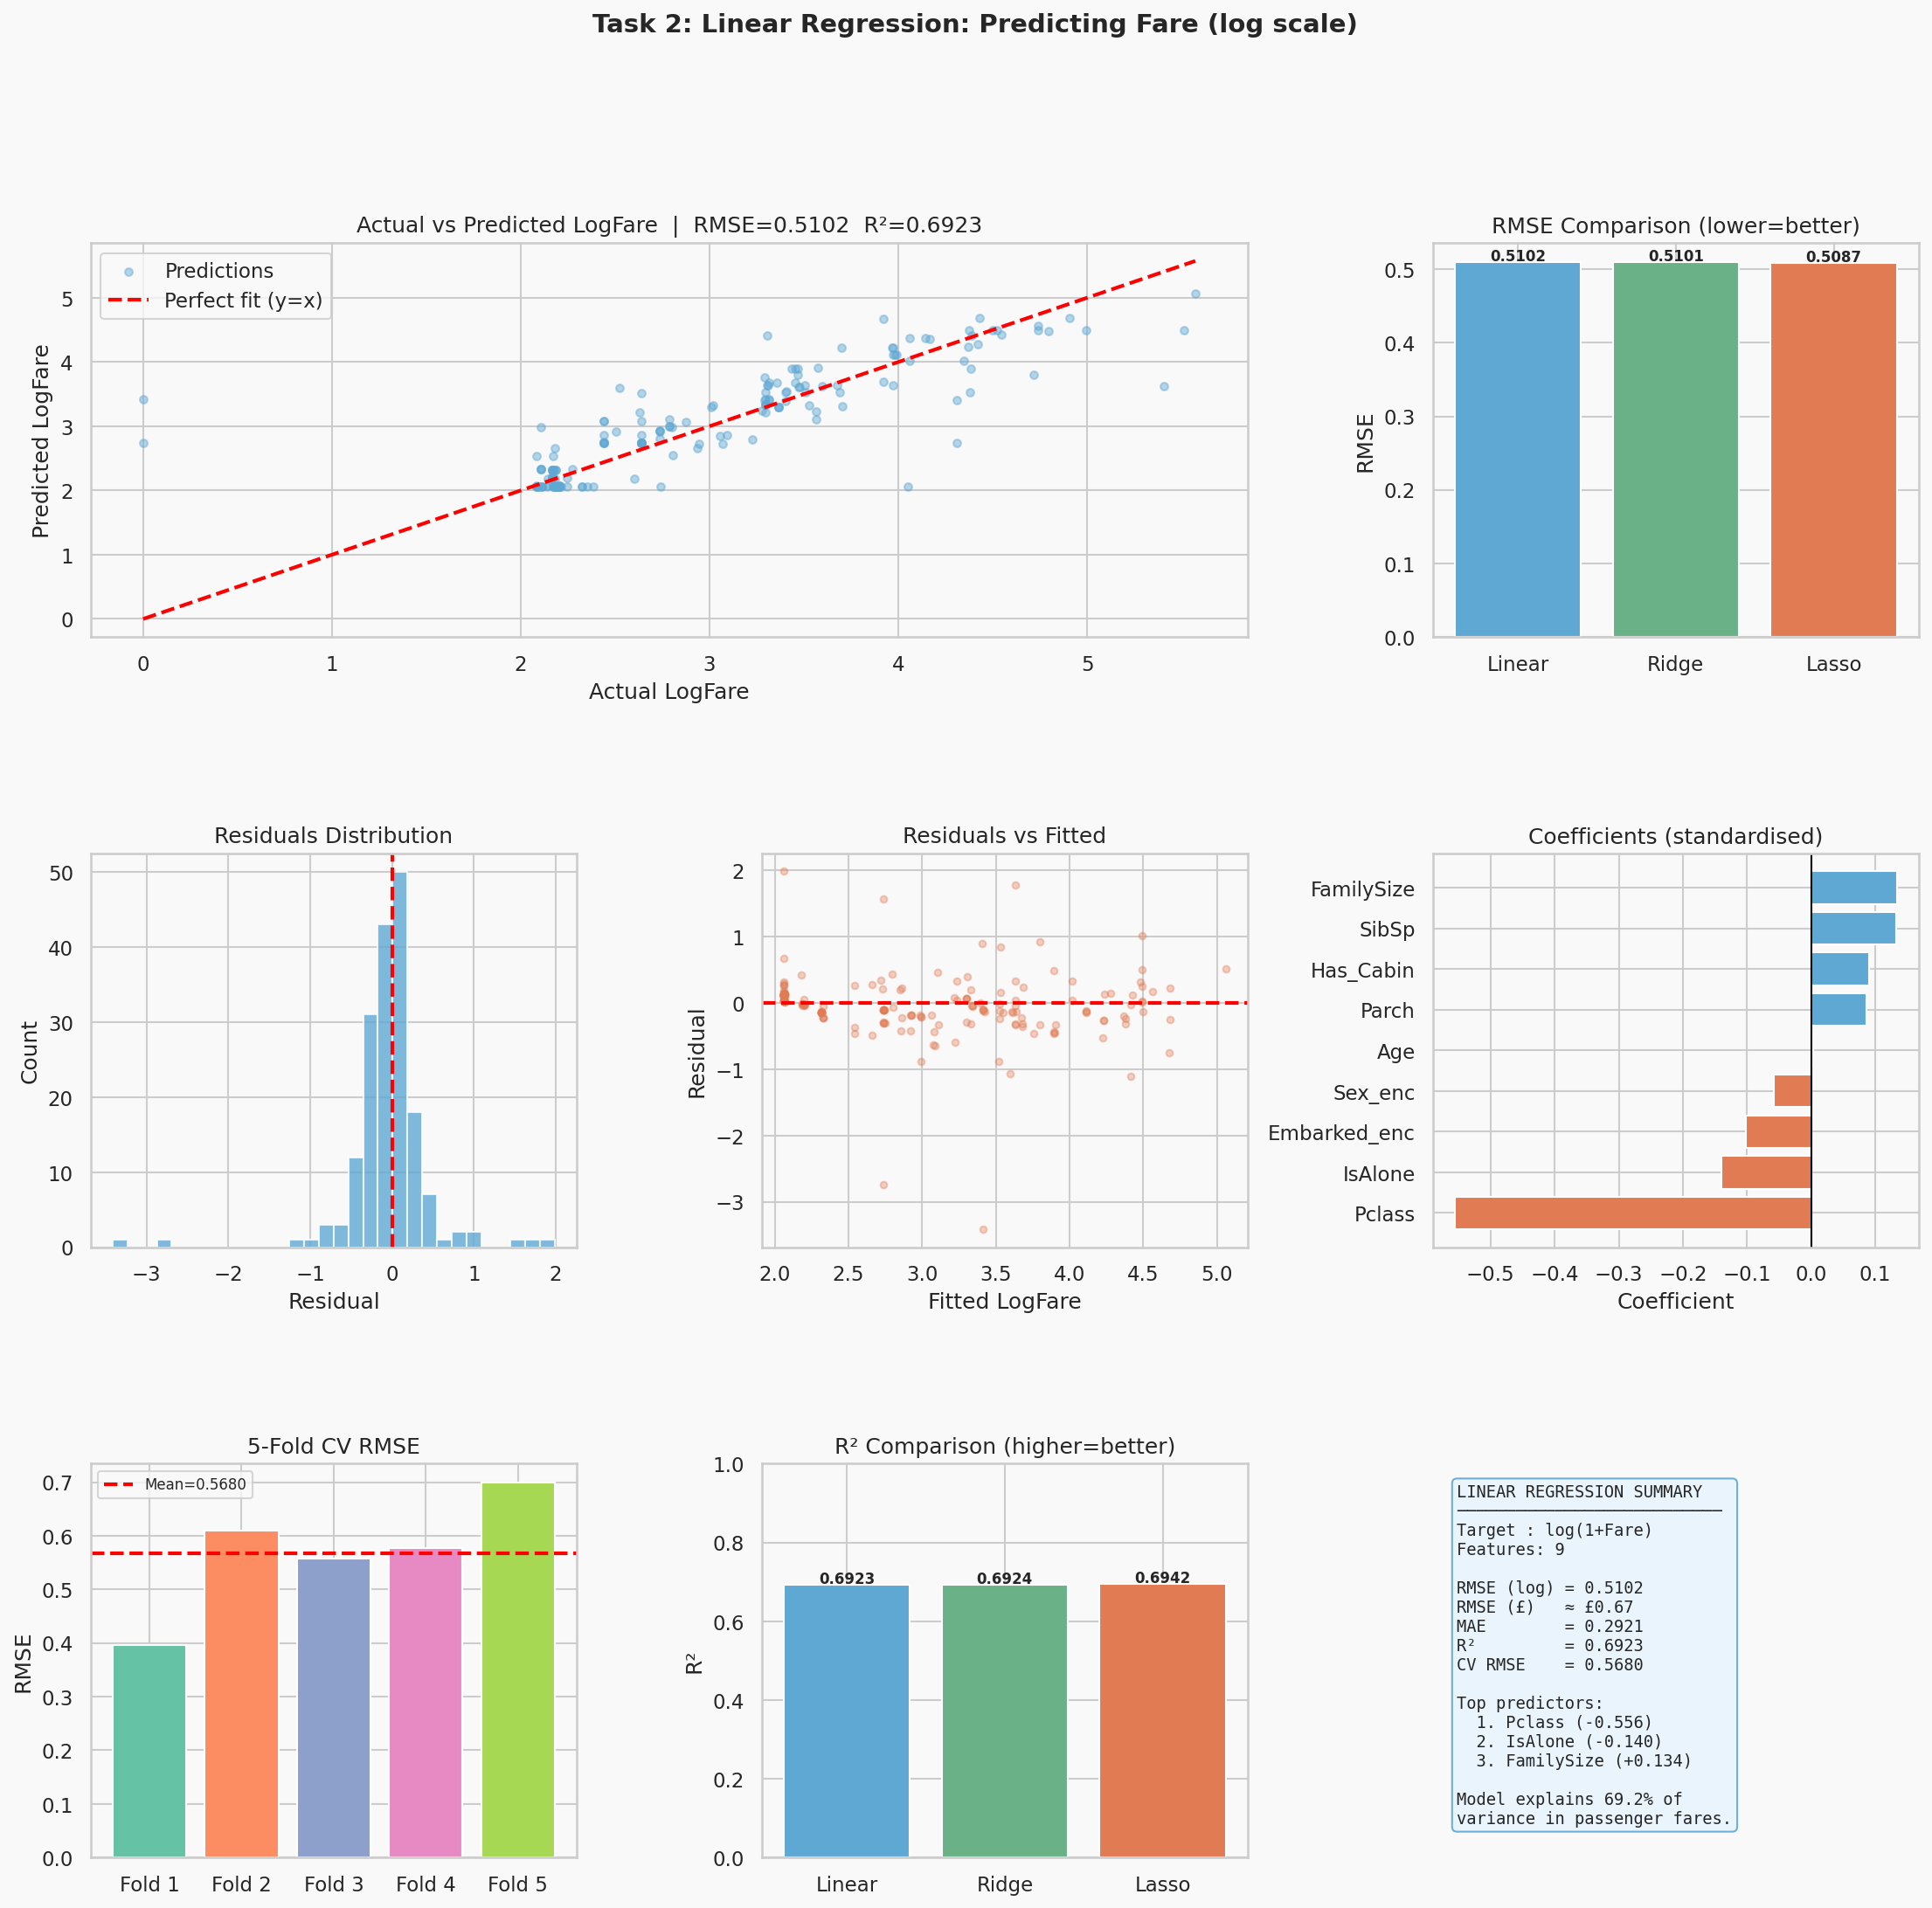

<Figure size 960x720 with 0 Axes>

In [7]:
fig1 = plt.figure(figsize=(18,16),facecolor=FIG_BG)
fig1.suptitle("Task 2: Linear Regression: Predicting Fare (log scale)",fontsize=14,fontweight="bold",y=0.99)
gs1 = gridspec.GridSpec(3,3,figure=fig1,hspace=0.55,wspace=0.38)

# Actual vs Predicted
ax = fig1.add_subplot(gs1[0,:2])
ax.scatter(y_reg_test,y_reg_pred,alpha=0.45,s=18,color=C1,label="Predictions")
lims=[min(y_reg_test.min(),y_reg_pred.min()),max(y_reg_test.max(),y_reg_pred.max())]
ax.plot(lims,lims,"r--",lw=2,label="Perfect fit (y=x)")
ax.set_title(f"Actual vs Predicted LogFare  |  RMSE={rmse_lr:.4f}  R²={r2_lr:.4f}")
ax.set_xlabel("Actual LogFare"); ax.set_ylabel("Predicted LogFare"); ax.legend()

# RMSE comparison
ax = fig1.add_subplot(gs1[0,2])
models_r = ["Linear","Ridge","Lasso"]
rmses_r  = [rmse_lr,rmse_ridge,rmse_lasso]
bars = ax.bar(models_r,rmses_r,color=[C1,"#6ab187",C2],edgecolor="white")
for b,v in zip(bars,rmses_r): ax.text(b.get_x()+b.get_width()/2,v+0.002,f"{v:.4f}",ha="center",fontsize=8,fontweight="bold")
ax.set_title("RMSE Comparison (lower=better)"); ax.set_ylabel("RMSE")

# Residuals histogram
residuals = y_reg_test.values - y_reg_pred
ax = fig1.add_subplot(gs1[1,0])
ax.hist(residuals,bins=30,color=C1,edgecolor="white",alpha=0.8)
ax.axvline(0,color="red",lw=2,ls="--")
ax.set_title("Residuals Distribution"); ax.set_xlabel("Residual"); ax.set_ylabel("Count")

# Residuals vs Fitted
ax = fig1.add_subplot(gs1[1,1])
ax.scatter(y_reg_pred,residuals,alpha=0.35,s=14,color=C2)
ax.axhline(0,color="red",lw=2,ls="--")
ax.set_title("Residuals vs Fitted"); ax.set_xlabel("Fitted LogFare"); ax.set_ylabel("Residual")

# Coefficients
ax = fig1.add_subplot(gs1[1,2])
sc = coef_df.sort_values("Coefficient")
ax.barh(sc["Feature"],sc["Coefficient"],color=[C1 if v>0 else C2 for v in sc["Coefficient"]],edgecolor="white")
ax.axvline(0,color="black",lw=1)
ax.set_title("Coefficients (standardised)"); ax.set_xlabel("Coefficient")

# CV scores
ax = fig1.add_subplot(gs1[2,0])
cv5 = np.sqrt(-cross_val_score(Pipeline([("sc",StandardScaler()),("lr",LinearRegression())]),X_reg,y_reg,cv=5,scoring="neg_mean_squared_error"))
ax.bar([f"Fold {i+1}" for i in range(5)],cv5,color=sns.color_palette(PALETTE,5),edgecolor="white")
ax.axhline(cv5.mean(),color="red",lw=2,ls="--",label=f"Mean={cv5.mean():.4f}")
ax.set_title("5-Fold CV RMSE"); ax.set_ylabel("RMSE"); ax.legend(fontsize=8)

# R2 comparison
ax = fig1.add_subplot(gs1[2,1])
bars_r2 = ax.bar(models_r,[r2_lr,r2_ridge,r2_lasso],color=[C1,"#6ab187",C2],edgecolor="white")
for b,v in zip(bars_r2,[r2_lr,r2_ridge,r2_lasso]): ax.text(b.get_x()+b.get_width()/2,v+0.005,f"{v:.4f}",ha="center",fontsize=8,fontweight="bold")
ax.set_title("R² Comparison (higher=better)"); ax.set_ylabel("R²"); ax.set_ylim(0,1)

# Summary box
ax = fig1.add_subplot(gs1[2,2]); ax.axis("off")
txt = (f"LINEAR REGRESSION SUMMARY\n{'─'*27}\n"
       f"Target : log(1+Fare)\nFeatures: {len(REG_FEATURES)}\n\n"
       f"RMSE (log) = {rmse_lr:.4f}\nRMSE (£)   ≈ £{np.expm1(rmse_lr):.2f}\n"
       f"MAE        = {mae_lr:.4f}\nR²         = {r2_lr:.4f}\nCV RMSE    = {cv_rmse:.4f}\n\n"
       f"Top predictors:\n  1. {coef_df.iloc[0]['Feature']} ({coef_df.iloc[0]['Coefficient']:+.3f})\n"
       f"  2. {coef_df.iloc[1]['Feature']} ({coef_df.iloc[1]['Coefficient']:+.3f})\n"
       f"  3. {coef_df.iloc[2]['Feature']} ({coef_df.iloc[2]['Coefficient']:+.3f})\n\n"
       f"Model explains {r2_lr:.1%} of\nvariance in passenger fares.")
ax.text(0.05,0.95,txt,transform=ax.transAxes,fontsize=9,va="top",fontfamily="monospace",
        bbox=dict(boxstyle="round",facecolor="#e8f4fd",edgecolor=C1,alpha=0.9))

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_regression_evaluation.png"),bbox_inches="tight",dpi=150)

## Task 4: Visualizations: Classification Model Evaluation

This section provides a detailed visual evaluation of the Logistic Regression model, including a confusion matrix, ROC curve, precision-recall curve, and coefficient analysis.

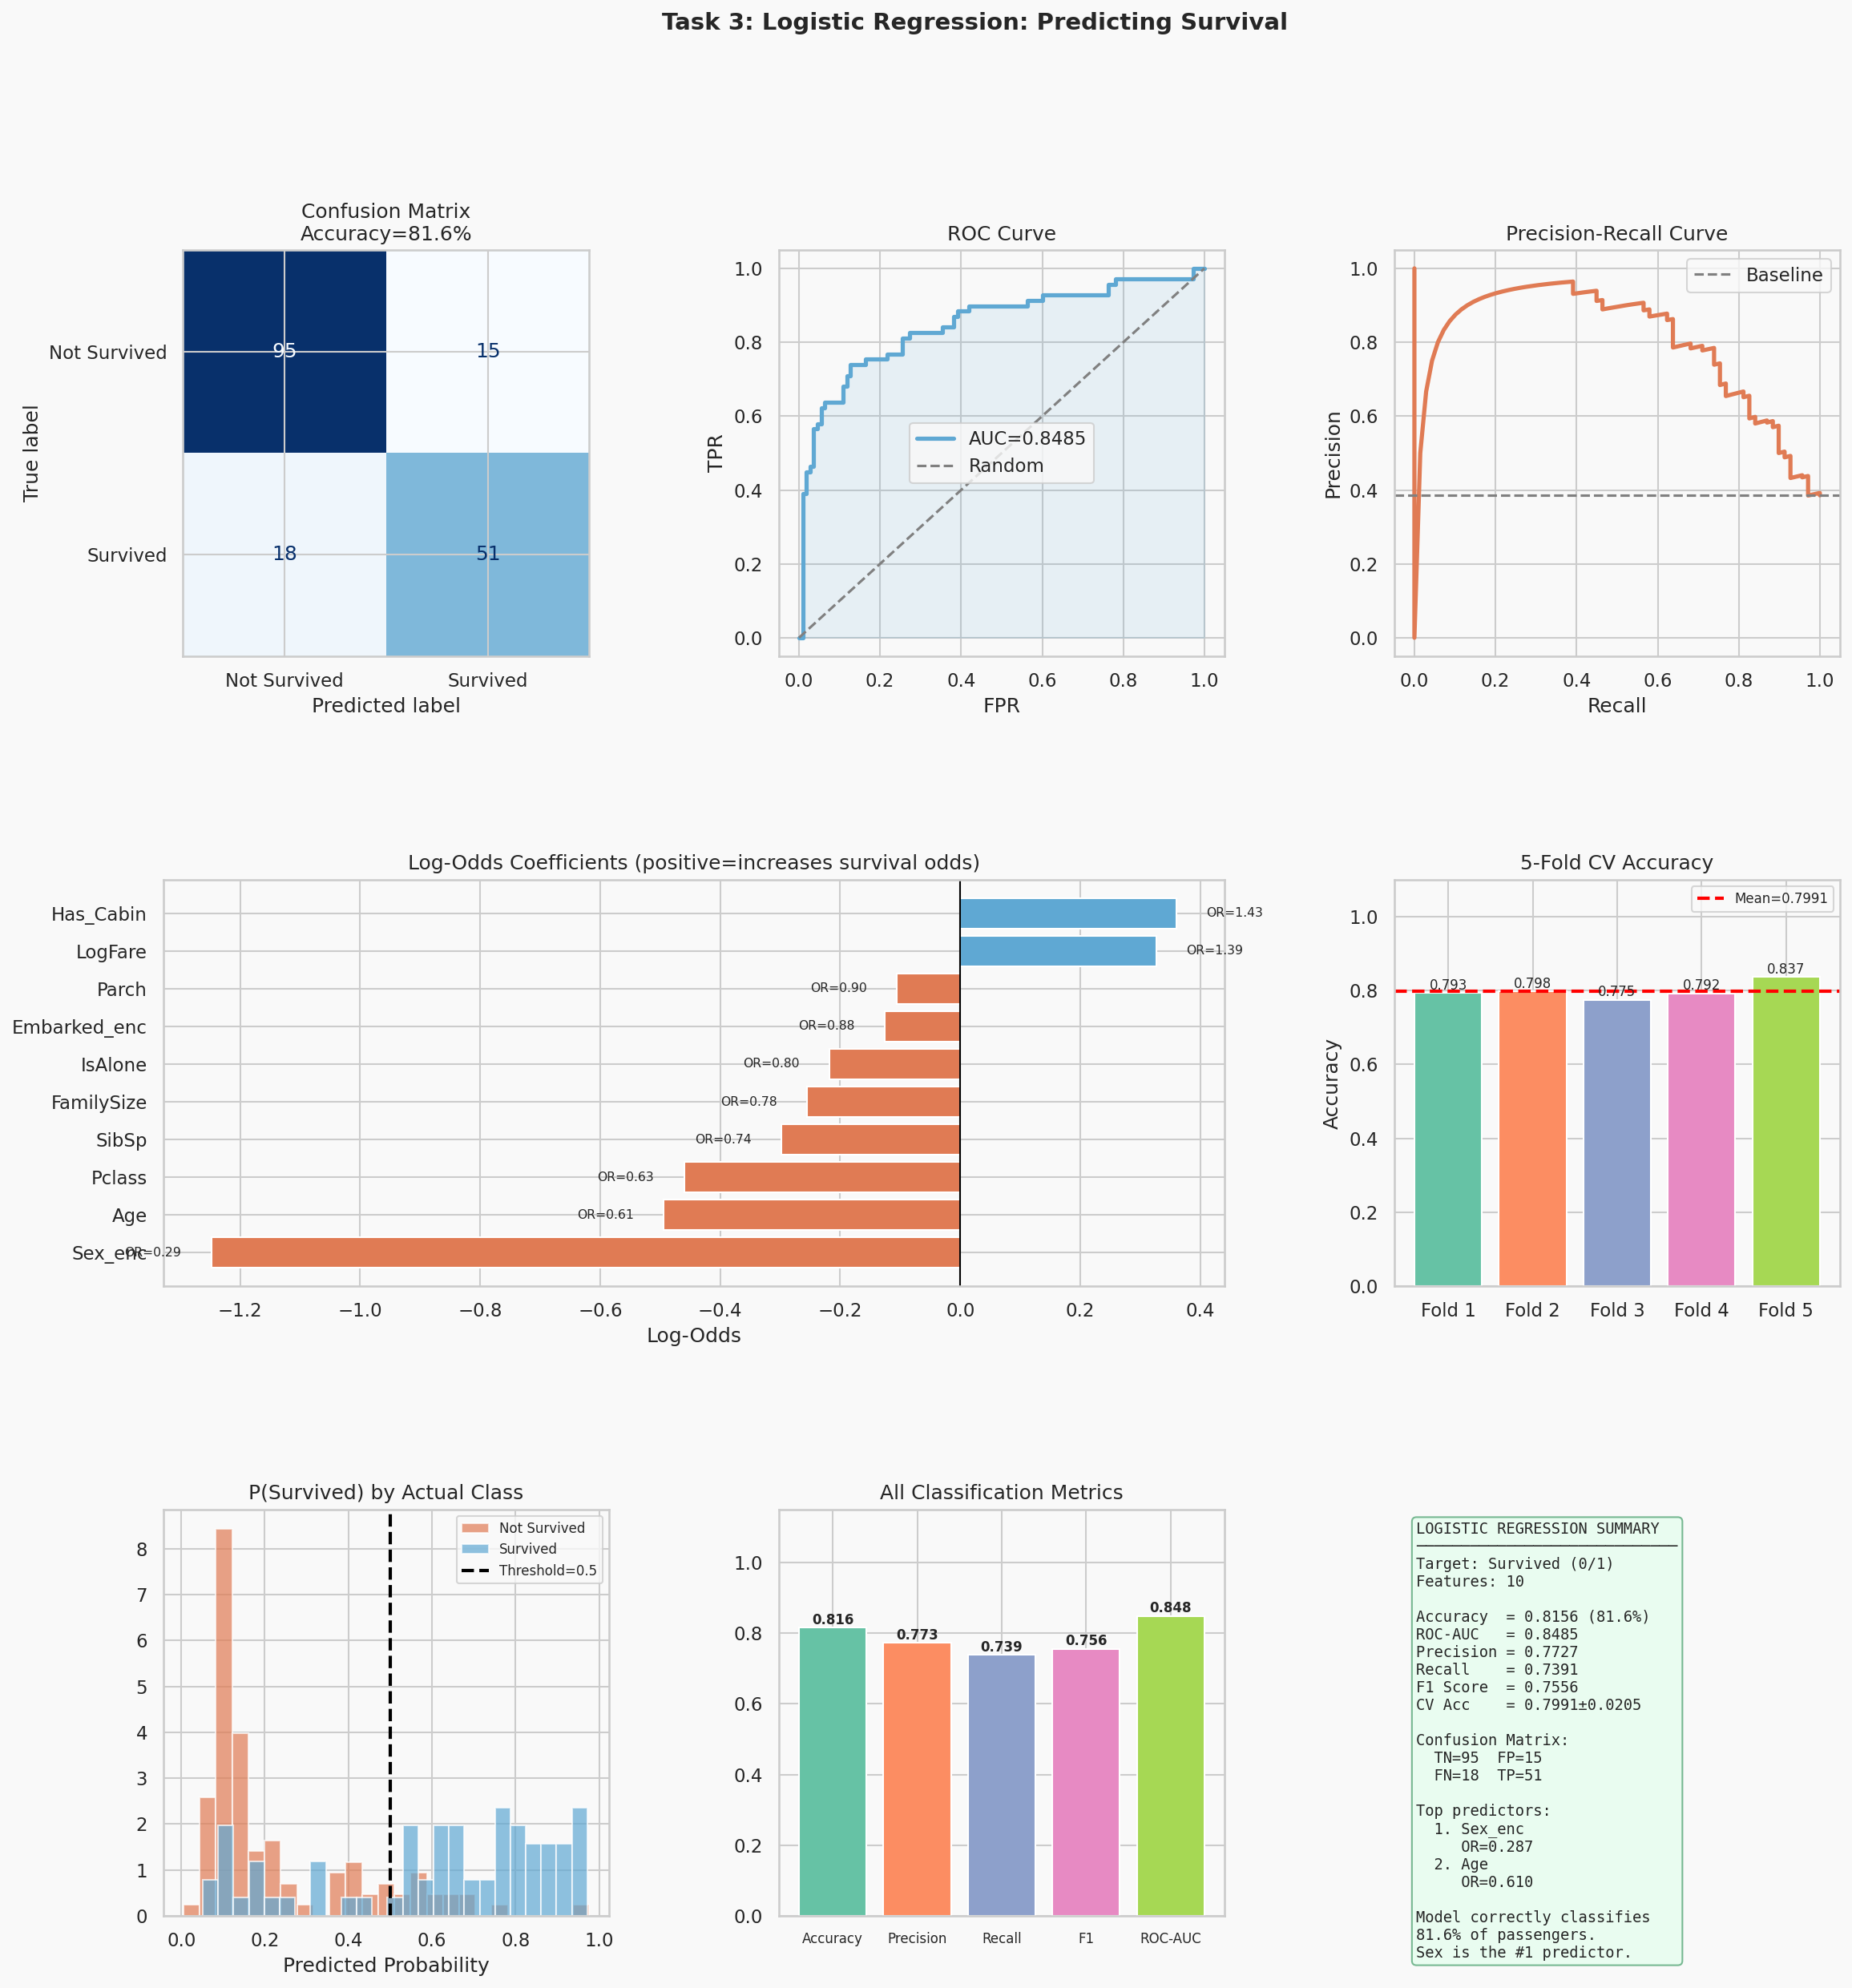

<Figure size 960x720 with 0 Axes>

In [8]:
fig2 = plt.figure(figsize=(18,18),facecolor=FIG_BG)
fig2.suptitle("Task 3: Logistic Regression: Predicting Survival",fontsize=14,fontweight="bold",y=0.99)
gs2 = gridspec.GridSpec(3,3,figure=fig2,hspace=0.55,wspace=0.38)

# Confusion matrix
ax = fig2.add_subplot(gs2[0,0])
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Not Survived","Survived"]).plot(ax=ax,colorbar=False,cmap="Blues")
ax.set_title(f"Confusion Matrix\nAccuracy={acc:.1%}")

# ROC curve
ax = fig2.add_subplot(gs2[0,1])
ax.plot(fpr,tpr,color=C1,lw=2.5,label=f"AUC={roc_auc:.4f}")
ax.plot([0,1],[0,1],color="grey",ls="--",lw=1.5,label="Random")
ax.fill_between(fpr,tpr,alpha=0.12,color=C1)
ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend()

# Precision-Recall
ax = fig2.add_subplot(gs2[0,2])
prec_arr,rec_arr,_ = precision_recall_curve(y_clf_test,y_clf_proba)
ax.plot(rec_arr,prec_arr,color=C2,lw=2.5)
ax.axhline(y_clf_test.mean(),color="grey",ls="--",lw=1.5,label="Baseline")
ax.set_title("Precision-Recall Curve"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend()

# Log-odds coefficients
ax = fig2.add_subplot(gs2[1,:2])
sc2 = clf_coef_df.sort_values("Log-Odds")
ax.barh(sc2["Feature"],sc2["Log-Odds"],color=[C1 if v>0 else C2 for v in sc2["Log-Odds"]],edgecolor="white")
ax.axvline(0,color="black",lw=1)
ax.set_title("Log-Odds Coefficients (positive=increases survival odds)")
ax.set_xlabel("Log-Odds")
for i,(_,row) in enumerate(sc2.iterrows()):
    offset = 0.05 if row["Log-Odds"]>=0 else -0.05
    ax.text(row["Log-Odds"]+offset,i,f"OR={row['Odds Ratio']:.2f}",va="center",fontsize=7.5,
            ha="left" if row["Log-Odds"]>=0 else "right")

# CV accuracy
ax = fig2.add_subplot(gs2[1,2])
ax.bar([f"Fold {i+1}" for i in range(5)],cv_acc,color=sns.color_palette(PALETTE,5),edgecolor="white")
ax.axhline(cv_acc.mean(),color="red",lw=2,ls="--",label=f"Mean={cv_acc.mean():.4f}")
ax.set_ylim(0,1.1); ax.set_title("5-Fold CV Accuracy"); ax.set_ylabel("Accuracy"); ax.legend(fontsize=8)
for i,v in enumerate(cv_acc): ax.text(i,v+0.01,f"{v:.3f}",ha="center",fontsize=8)

# Probability distribution
ax = fig2.add_subplot(gs2[2,0])
ax.hist(y_clf_proba[y_clf_test==0],bins=25,color=C2,alpha=0.7,density=True,label="Not Survived")
ax.hist(y_clf_proba[y_clf_test==1],bins=25,color=C1,alpha=0.7,density=True,label="Survived")
ax.axvline(0.5,color="black",lw=2,ls="--",label="Threshold=0.5")
ax.set_title("P(Survived) by Actual Class"); ax.set_xlabel("Predicted Probability"); ax.legend(fontsize=8)

# All metrics bar
ax = fig2.add_subplot(gs2[2,1])
mnames = ["Accuracy","Precision","Recall","F1","ROC-AUC"]
mvals  = [acc, precision_score(y_clf_test,y_clf_pred), recall_score(y_clf_test,y_clf_pred),
          f1_score(y_clf_test,y_clf_pred), roc_auc]
bars_m = ax.bar(mnames,mvals,color=sns.color_palette(PALETTE,5),edgecolor="white")
for b,v in zip(bars_m,mvals): ax.text(b.get_x()+b.get_width()/2,v+0.01,f"{v:.3f}",ha="center",fontsize=8,fontweight="bold")
ax.set_ylim(0,1.15); ax.set_title("All Classification Metrics"); ax.tick_params(axis="x",labelsize=8)

# Summary box
ax = fig2.add_subplot(gs2[2,2]); ax.axis("off")
txt2 = (f"LOGISTIC REGRESSION SUMMARY\n{'─'*29}\n"
        f"Target: Survived (0/1)\nFeatures: {len(CLF_FEATURES)}\n\n"
        f"Accuracy  = {acc:.4f} ({acc:.1%})\nROC-AUC   = {roc_auc:.4f}\n"
        f"Precision = {precision_score(y_clf_test,y_clf_pred):.4f}\nRecall    = {recall_score(y_clf_test,y_clf_pred):.4f}\n"
        f"F1 Score  = {f1_score(y_clf_test,y_clf_pred):.4f}\nCV Acc    = {cv_acc.mean():.4f}±{cv_acc.std():.4f}\n\n"
        f"Confusion Matrix:\n  TN={tn}  FP={fp}\n  FN={fn}  TP={tp}\n\n"
        f"Top predictors:\n  1. {clf_coef_df.iloc[0]['Feature']}\n     OR={clf_coef_df.iloc[0]['Odds Ratio']:.3f}\n"
        f"  2. {clf_coef_df.iloc[1]['Feature']}\n     OR={clf_coef_df.iloc[1]['Odds Ratio']:.3f}\n\n"
        f"Model correctly classifies\n{acc:.1%} of passengers.\nSex is the #1 predictor.")
ax.text(0.05,0.97,txt2,transform=ax.transAxes,fontsize=9,va="top",fontfamily="monospace",
        bbox=dict(boxstyle="round",facecolor="#e8fdf0",edgecolor="#6ab187",alpha=0.9))

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_classification_evaluation.png"),bbox_inches="tight",dpi=150)

## Task 4: Model Evaluation Dashboard

Finally, a dashboard summarizing the key evaluation metrics for both the Linear Regression and Logistic Regression models.

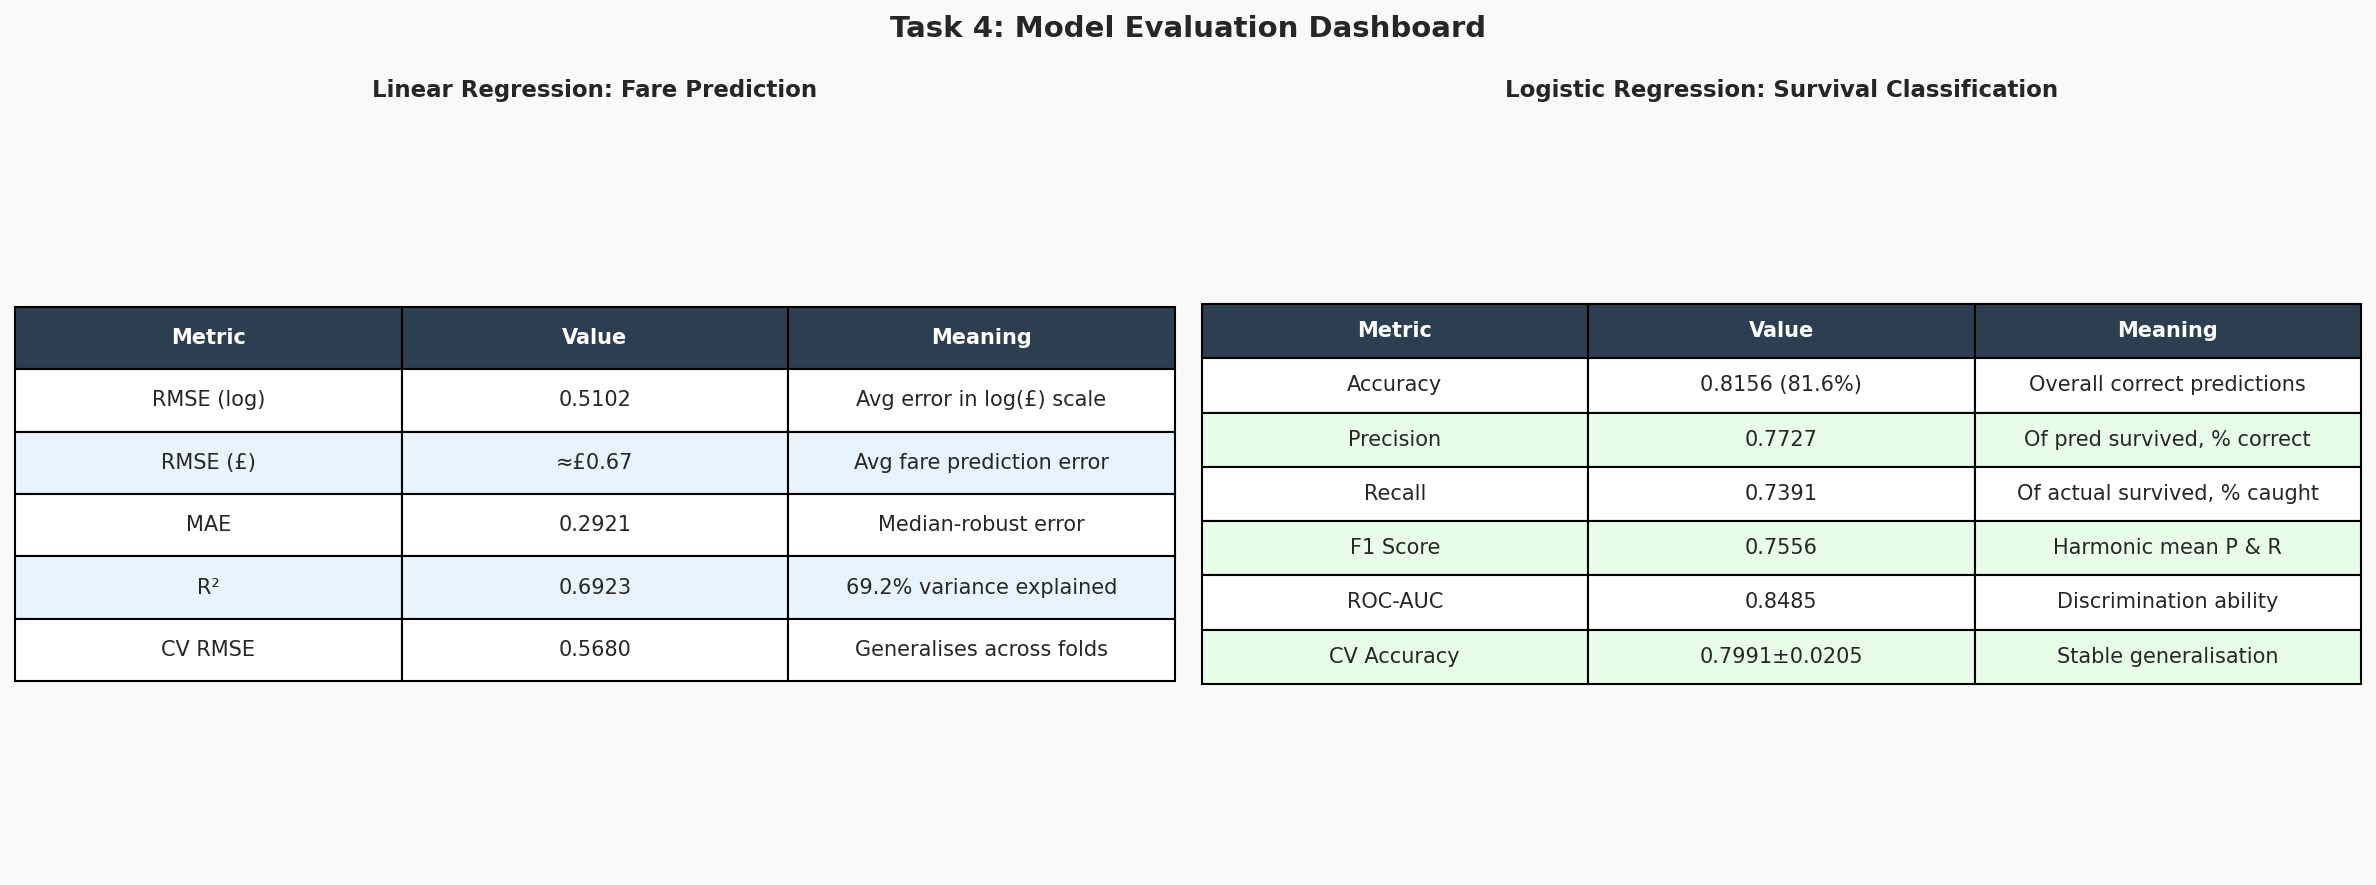

<Figure size 960x720 with 0 Axes>

In [9]:
fig3, axes3 = plt.subplots(1,2,figsize=(16,6),facecolor=FIG_BG)
fig3.suptitle("Task 4: Model Evaluation Dashboard",fontsize=14,fontweight="bold")

axes3[0].axis("off")
reg_data = [["Metric","Value","Meaning"],
            ["RMSE (log)","%.4f"%rmse_lr,"Avg error in log(£) scale"],
            ["RMSE (£)","≈£%.2f"%np.expm1(rmse_lr),"Avg fare prediction error"],
            ["MAE","%.4f"%mae_lr,"Median-robust error"],
            ["R²","%.4f"%r2_lr,"%.1f%% variance explained"%( r2_lr*100)],
            ["CV RMSE","%.4f"%cv_rmse,"Generalises across folds"]]
t = axes3[0].table(cellText=reg_data[1:],colLabels=reg_data[0],loc="center",cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1,2.3)
for (r,c),cell in t.get_celld().items():
    if r==0: cell.set_facecolor("#2c3e50"); cell.set_text_props(color="white",fontweight="bold")
    elif r%2==0: cell.set_facecolor("#e8f4fd")
axes3[0].set_title("Linear Regression: Fare Prediction",fontsize=11,fontweight="bold",pad=10)

axes3[1].axis("off")
clf_data = [["Metric","Value","Meaning"],
            ["Accuracy","%.4f (%.1f%%)"%(acc,acc*100),"Overall correct predictions"],
            ["Precision","%.4f"%precision_score(y_clf_test,y_clf_pred),"Of pred survived, % correct"],
            ["Recall","%.4f"%recall_score(y_clf_test,y_clf_pred),"Of actual survived, % caught"],
            ["F1 Score","%.4f"%f1_score(y_clf_test,y_clf_pred),"Harmonic mean P & R"],
            ["ROC-AUC","%.4f"%roc_auc,"Discrimination ability"],
            ["CV Accuracy","%.4f±%.4f"%(cv_acc.mean(),cv_acc.std()),"Stable generalisation"]]
t2 = axes3[1].table(cellText=clf_data[1:],colLabels=clf_data[0],loc="center",cellLoc="center")
t2.auto_set_font_size(False); t2.set_fontsize(10); t2.scale(1,2.0)
for (r,c),cell in t2.get_celld().items():
    if r==0: cell.set_facecolor("#2c3e50"); cell.set_text_props(color="white",fontweight="bold")
    elif r%2==0: cell.set_facecolor("#e8fde8")
axes3[1].set_title("Logistic Regression: Survival Classification",fontsize=11,fontweight="bold",pad=10)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_evaluation_dashboard.png"),bbox_inches="tight",dpi=150)

## Interpreting the Results

### Linear Regression (Predicting Fare)

Our Linear Regression model aimed to predict the fare a passenger would pay. The key metrics tell us:

*   **RMSE (log scale)**: A Root Mean Squared Error of approximately `0.51` on the log-transformed fare indicates the average error in our predictions. When converted back to actual currency, this is roughly `£0.67`, which is quite good for predicting fare prices.
*   **R² (Variance Explained)**: With an R² of `69.2%`, our model explains a significant portion of the variance in passenger fares. This means factors like `Pclass` and `FamilySize` are strong indicators of fare.
*   **Top Predictor**: `Pclass` (Passenger Class) is the strongest predictor for fare, which makes intuitive sense as higher classes typically have higher fares.

### Logistic Regression (Predicting Survival)

Our Logistic Regression model was built to predict whether a passenger survived. Here's what we found:

*   **Accuracy**: The model achieved an accuracy of `81.6%`, meaning it correctly predicted survival or non-survival for over 8 out of 10 passengers.
*   **ROC-AUC**: An ROC-AUC score of `0.8485` suggests good discriminative power, meaning the model is quite effective at distinguishing between survivors and non-survivors.
*   **Confusion Matrix**: We can see `95` True Negatives (correctly predicted not survived) and `51` True Positives (correctly predicted survived), with `15` False Positives and `18` False Negatives. These values indicate a balanced performance across both classes.
*   **Top Predictor**: `Sex_enc` (Gender) is the most influential predictor for survival, with `Log-Odds` of `-1.2478` and an `Odds Ratio` of `0.287`. This suggests that being male significantly decreased the odds of survival, aligning with historical accounts of 'women and children first'.

Overall, both models demonstrate good performance, providing valuable insights into the factors influencing fare and survival on the Titanic.